In [1]:
%matplotlib inline
import sys, os, glob

from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

In [2]:
import scienceplots

plt.style.use(['bright', 'science', 'no-latex', 'notebook'])

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["svg.fonttype"] = "none"

In [3]:
hdul = fits.open('../stripe82_quasars/dr16q_prop_May01_2024.fits')
hdul[1].header
data_sdss = hdul[1].data
data_sdss = data_sdss[(data_sdss['SN_MEDIAN_ALL'] > 2) & (data_sdss['LOGMBH'] > 0) & (data_sdss['LOGMBH'] < 11)]

# From Qiaya: Now I am pretty confidence that you can remove all MBH>1e11 objs. After visually inspection, 
# I found that most of them are not quasar, a few have incorrect redshift, one or two underestimated the continuum.

In [4]:
data_dwarf_AGN = ascii.read('franklin_broad_line_dwarf_agn.txt')
print(np.unique(data_dwarf_AGN['catalog']))

# I think Chilingarian should include the RGG sources
data_dwarf_AGN = data_dwarf_AGN[data_dwarf_AGN['catalog']!='RV15']

# Remove duplicates
cat_dwarf_AGN = SkyCoord(data_dwarf_AGN['ra'], data_dwarf_AGN['dec'], unit='deg')
idx,idx,d2d,d3d = cat_dwarf_AGN.search_around_sky(cat_dwarf_AGN, 1*u.arcsec)
#idx = np.unique(idx)
data_dwarf_AGN = data_dwarf_AGN[idx]

    catalog    
---------------
Chilingarian+18
           GH07
         Liu+18
           RV15


In [5]:
len(cat_dwarf_AGN)

673

In [6]:
len(np.unique(idx))

673

In [7]:
# Read BlackCAT (dynamical BH mass catalog)
# https://cdsarc.cds.unistra.fr/viz-bin/cat/J/A+A/587/A61#/browse
data_XRB = ascii.read('blackcat_4.txt', header_start=0, delimiter='|')
data_XRB

Name,e,Ctp,SpType,Porb,e_Porb,2,K2,e_K2,f(M1),(M1),M1,M1_1,_M1,e_ M1u,_q,q,E_q,e_ qu,_i,i,e_ iu,ni,tsini,sini,sini_1,Ref
str18,str1,str10,str7,float64,float64,str1,float64,float64,float64,float64,str2,float64,float64,str5,str2,str5,float64,float64,str2,float64,float64,str2,str5,float64,float64,str81
SWIFT J1357.2-0933,+,--,M2-4V,2.8,0.3,--,967.0,49.0,11.0,2.1,>,8.9,--,--,~,0.04,--,--,~,90.0,--,--,--,--,--,Corral-Santana2013;MataSanchez2015
XTE J1650-500,--,--,~K4V,7.69,0.02,--,435.0,30.0,2.7,0.6,<=,7.3,--,--,--,---,--,--,>,47.0,--,--,--,--,--,Orosz2004
XTE J1118+480,--,--,K7-M1V,4.078414,5e-06,--,709.0,1.0,6.27,0.04,--,6.9,--,- 8.2,--,0.024,0.009,0.009,--,68.0,-79.0,--,96.,3.0,11.0,Khargharia2013;Torres2004;GonzalezHernandez2008;Calvelo2009
XTE J1859+226,--,V406 Vul,~K5V,6.58,0.05,--,541.0,70.0,4.5,0.6,>,5.42,--,--,--,---,--,--,<,70.0,--,--,--,--,--,Corral-Santana2011
SAX J1819.3-2525,--,V4641 Sgr,B9III,67.6152,0.0002,--,211.0,3.0,2.7,0.1,--,6.4,0.6,0.6,--,0.63,--,-0.7,--,72.0,4.0,--,100.9,0.8,0.8,Orosz2001;MacDonald2014
XTE J1550-564,--,--,K2-K4IV,37.0088,0.0001,--,363.0,6.0,7.65,0.38,--,7.81,--,-15.6,~~,0.03,--,--,--,75.0,4.0,--,55.,5.0,5.0,Orosz2002;Orosz2011b
GRO J1655-40,--,N. Sco 94,F6IV,62.92,0.003,--,226.1,0.8,2.73,0.09,--,6.0,0.4,0.4,--,0.42,0.03,0.03,--,69.0,2.0,--,86.,3.3,3.6,Orosz1997;VanDerHooft1998;Shahbaz1999;Shahbaz2003;Beer2002;GonzalezHernandez2008a
GRS 1009-45,--,N. Vel 93,K7-M0V,6.8449,0.0003,--,475.0,6.0,3.2,0.1,>~,4.4,--,--,--,0.14,0.02,0.02,--,37.0,-80.0,--,---,--,--,Filippenko1999;Shahbaz1996
GRS 1915+105,--,V1487 Aql,K1-5III,812.0,4.0,--,126.0,1.0,7.0,0.2,--,10.1,0.6,0.6,--,0.042,0.024,0.024,--,66.0,2.0,--,21.,4.0,4.0,Harlaftis2004;Steeghs2013;Fender1999


In [8]:
# https://gwosc.org/eventapi/
data_GW = ascii.read('GWTC-4.txt')
data_GW

id,commonName,version,catalog.shortName,GPS,reference,jsonurl,mass_1_source,mass_1_source_lower,mass_1_source_upper,mass_2_source,mass_2_source_lower,mass_2_source_upper,network_matched_filter_snr,network_matched_filter_snr_lower,network_matched_filter_snr_upper,luminosity_distance,luminosity_distance_lower,luminosity_distance_upper,chi_eff,chi_eff_lower,chi_eff_upper,total_mass_source,total_mass_source_lower,total_mass_source_upper,chirp_mass_source,chirp_mass_source_lower,chirp_mass_source_upper,chirp_mass,chirp_mass_lower,chirp_mass_upper,redshift,redshift_lower,redshift_upper,far,far_lower,far_upper,p_astro,p_astro_lower,p_astro_upper,final_mass_source,final_mass_source_lower,final_mass_source_upper
str18,str15,int64,str18,float64,str33,str69,str5,str5,str5,str5,str5,str4,float64,str4,str4,str6,str7,str7,str5,str5,str4,str5,str5,str5,str5,str6,str5,str4,str4,str4,str4,str5,str4,float64,str4,str4,float64,str4,str4,str5,str5,str5
GW150914-v3,GW150914,3,GWTC-1-confident,1126259462.4,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3,35.6,-3.1,4.7,30.6,-4.4,3.0,26.0,-0.2,0.1,440.0,-170.0,150.0,-0.01,-0.13,0.12,None,None,None,28.6,-1.5,1.7,None,None,None,0.09,-0.03,0.03,1e-07,None,None,1.0,None,None,63.1,-3.0,3.4
GW151012-v3,GW151012,3,GWTC-1-confident,1128678900.4,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW151012/v3,23.2,-5.5,14.9,13.6,-4.8,4.1,10.0,None,None,1080.0,-490.0,550.0,0.05,-0.2,0.31,None,None,None,15.2,-1.2,2.1,None,None,None,0.21,-0.09,0.09,0.00792,None,None,1.0,None,None,35.6,-3.8,10.8
GW151226-v2,GW151226,2,GWTC-1-confident,1135136350.6,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW151226/v2,13.7,-3.2,8.8,7.7,-2.5,2.2,13.1,None,None,450.0,-190.0,180.0,0.18,-0.12,0.2,None,None,None,8.9,-0.3,0.3,None,None,None,0.09,-0.04,0.04,1e-07,None,None,1.0,None,None,20.5,-1.5,6.4
GW170104-v2,GW170104,2,GWTC-1-confident,1167559936.6,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170104/v2,30.8,-5.6,7.3,20.0,-4.6,4.9,13.8,-0.3,0.2,990.0,-430.0,440.0,-0.04,-0.21,0.17,None,None,None,21.4,-1.8,2.2,None,None,None,0.2,-0.08,0.08,1e-07,None,None,1.0,None,None,48.9,-4.0,5.1
GW170608-v3,GW170608,3,GWTC-1-confident,1180922494.5,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170608/v3,11.0,-1.7,5.5,7.6,-2.2,1.4,15.4,None,None,320.0,-110.0,120.0,0.03,-0.07,0.19,None,None,None,7.9,-0.2,0.2,None,None,None,0.07,-0.02,0.02,1e-07,None,None,1.0,None,None,17.8,-0.7,3.4
GW170729-v1,GW170729,1,GWTC-1-confident,1185389807.3,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170729/v1,50.2,-10.2,16.2,34.0,-10.1,9.1,10.8,None,None,2840.0,-1360.0,1400.0,0.37,-0.25,0.21,None,None,None,35.4,-4.8,6.5,None,None,None,0.49,-0.21,0.19,0.02,None,None,0.98,None,None,79.5,-10.2,14.7
GW170809-v1,GW170809,1,GWTC-1-confident,1186302519.8,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170809/v1,35.0,-5.9,8.3,23.8,-5.2,5.1,12.8,-0.3,0.2,1030.0,-390.0,320.0,0.08,-0.17,0.17,None,None,None,24.9,-1.7,2.1,None,None,None,0.2,-0.07,0.05,1e-07,None,None,1.0,None,None,56.3,-3.8,5.2
GW170814-v3,GW170814,3,GWTC-1-confident,1186741861.5,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170814/v3,30.6,-3.0,5.6,25.2,-4.0,2.8,17.7,-0.3,0.2,600.0,-220.0,150.0,0.07,-0.12,0.12,None,None,None,24.1,-1.1,1.4,None,None,None,0.12,-0.04,0.03,1e-07,None,None,1.0,None,None,53.2,-2.4,3.2
GW170817-v3,GW170817,3,GWTC-1-confident,1187008882.4,https://doi.org/10.7935/82H3-HH23,https://gwosc.org/eventapi/json/GWTC-1-confident/GW170817/v3,1.46,-0.1,0.12,1.27,-0.09,0.09,33.0,None,None,40.0,-15.0,7.0,0.0,-0.01,0.02,None,None,None,1.186,-0.001,0.001,None,None,None,0.01,0.0,0.0,1e-07,None,None,1.0,None,None,2.8,None,None


In [9]:
M1 = data_GW['mass_1_source']
M1

35.6
23.2
13.7
30.8
11.0
50.2
35.0
30.6
1.46
35.4
39.5


In [10]:
# https://academic.oup.com/mnras/article/471/2/1694/4056151
logMBH_TDE = np.array([5.50, 6.23, 5.42, 6.31, 6.88, 6.34, 5.68, 7.25, 5.85, 5.82, 6.21, 7.36])

In [11]:
from astropy.table import Table
from io import StringIO
import re
from astropy.table import vstack

def read_tex_tabular_with_astropy(path, clean_math=True, nodata_to_empty=True):
    """
    Read the FIRST \begin{tabular}...\end{tabular} block from a LaTeX file
    into an Astropy Table using format='ascii.latex'.
    """
    in_tabular = False
    captured = []

    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.rstrip("\n")

            if not in_tabular and r"\begin{tabular" in line:
                in_tabular = True
                captured.append(line)              # keep \begin{tabular}{...}
                continue

            if in_tabular:
                if r"\end{tabular}" in line:
                    captured.append(line)          # keep \end{tabular}
                    break
                if r"\hline" in line.strip():
                    continue                       # drop horizontal rules

                s = line
                if clean_math:
                    # strip $...$ wrappers (keeps inner text)
                    s = re.sub(r"\$(.*?)\$", r"\1", s)
                if nodata_to_empty:
                    s = s.replace(r"\nodata", "")
                captured.append(s)

    if not captured:
        raise RuntimeError("No \\begin{tabular}...\\end{tabular} block found in file.")

    tex_block = "\n".join(captured)

    # IMPORTANT: pass the STRING directly, not a StringIO
    try:
        table = Table.read(tex_block, format="ascii.latex", guess=False)
        return table
    except Exception as e:
        # Minimal fallback: remove caption-like lines that sometimes sneak in
        tex_block2 = "\n".join(
            ln for ln in captured
            if not ln.strip().startswith(("%", r"\caption", r"\label"))
        )
        table = Table.read(tex_block2, format="ascii.latex", guess=False)
        return table

def parse_mass_column(col):
    """
    Parses an Astropy Table column of strings like:
    - '(4.7 \\pm1.0) \\times 10^4'
    - '(6.8_{-2.2}^{+32}) \\times 10^3'
    - '6.8_{-2.2}^{+32}) \\times 10^3'
    - '6.8) \\times 10^3'
    - '(2000 \\pm 1000)'
    - '(2.8 \\pm 0.4) \\times 10^4'
    - '3000'
    - '1700-3200'
    - '2.1e5'
    and returns a numpy array of floats.
    """
    vals = []
    for s in col:
        s = str(s).strip()
        # Handle range: e.g., '1700-3200'
        range_match = re.match(r'^\s*([0-9.eE+-]+)\s*-\s*([0-9.eE+-]+)\s*$', s)
        if range_match:
            v1, v2 = map(float, range_match.groups())
            vals.append(0.5 * (v1 + v2))
            continue
        # Remove parentheses
        s = s.replace('(', '').replace(')', '').strip()
        # Remove \pm error notation
        s = re.sub(r'\\pm\s*[0-9.eE+-]+', '', s)
        # Remove _{...}^{...} error notation
        s = re.sub(r'_\{[-+0-9.eE]+\}\^\{\+?[-+0-9.eE]+\}', '', s)
        s = s.strip()
        # Scientific notation with \times 10^
        match = re.match(r'([0-9.]+)\s*\\times\s*10\^([0-9+-]+)', s)
        if match:
            base, exp = match.groups()
            try:
                val = float(base) * 10**float(exp)
            except Exception:
                val = np.nan
        else:
            # Try to just convert to float if no exponent
            try:
                val = float(s)
            except Exception:
                val = np.nan
        vals.append(val)
    return np.array(vals)

# Example usage:
table_off_nuclear = read_tex_tabular_with_astropy("imbh_off_nuclear.tex")
table_nuclear = read_tex_tabular_with_astropy("imbh_nuclear.tex")

table_nuclear = table_nuclear[table_nuclear['Method']=='Dynamics']
table_off_nuclear = table_off_nuclear[table_off_nuclear['Method']=='Dynamics']

mask = ~np.char.startswith(table_nuclear['M_{\\rm BH}'].astype(str), '<') & ~np.char.startswith(table_nuclear['M_{\\rm BH}'].astype(str), '>')
table_nuclear = table_nuclear[mask]

mask = ~np.char.startswith(table_off_nuclear['M_{\\rm BH}'].astype(str), '<') & ~np.char.startswith(table_off_nuclear['M_{\\rm BH}'].astype(str), '>')
table_off_nuclear = table_off_nuclear[mask]

# Clean duplicates (older duplicates dropped)
table_off_nuclear = table_off_nuclear[table_off_nuclear['Ref'] != 14]
table_off_nuclear = table_off_nuclear[table_off_nuclear['Ref'] != 11]

# Convert mass
table_nuclear['M_BH'] = parse_mass_column(table_nuclear['M_{\\rm BH}'])
table_off_nuclear['M_BH'] = parse_mass_column(table_off_nuclear['M_{\\rm BH}'])

combined_table = vstack([table_nuclear['Object', 'M_BH'], table_off_nuclear['Object', 'M_BH']])
combined_table


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_6131/77065141.py:7: SyntaxWarning: invalid escape sequence '\e'
  """


Object,M_BH
str12,float64
NGC205,6800.0
NGC5102,910000.0
NGC5206,630000.0
NGC4395,400000.0
47 Tuc,2300.0
\omega Cen,47000.0
M62,2000.0
M15,2450.0
NGC6388,28000.0


In [12]:
table_off_nuclear

Object,Dist,Method,M_{\rm BH},M_{\rm cluster},\sigma^*,Ref,M_BH
str12,float64,str13,str25,str28,float64,int64,float64
47 Tuc,0.005,Dynamics,2300,7.8 \times 10^5,12.2,1,2300.0
\omega Cen,0.005,Dynamics,(4.7 \pm1.0) \times 10^4,3.6 \times 10^6,17.6,4,47000.0
M62,0.007,Dynamics,(2000 \pm 1000),7.1 \times 10^5,15.2,6,2000.0
M15,0.01,Dynamics,1700-3200,4.5 \times 10^5,12.9,10,2450.0
NGC6388,0.011,Dynamics,(2.8 \pm 0.4) \times 10^4,1.1 \times 10^6,13.1,12,28000.0
NGC1904,0.013,Dynamics,(3000 \pm 1000),1.7 \times 10^5,8.7,6,3000.0
M54,0.024,Dynamics,1.1 \times 10^4,1.4 \times 10^6,20.2,15,11000.0
M31/G1,0.78,Dynamics,(1.8\pm0.5) \times 10^4,3.1 \times 10^6,25.8,16,18000.0


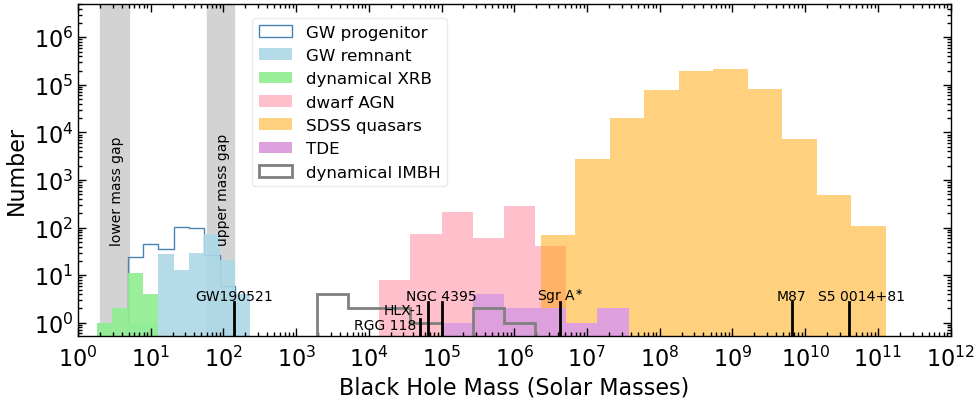

In [13]:
import matplotlib

# Figure inspired by https://arxiv.org/pdf/1610.05309.pdf

mask = (data_GW['mass_1_source'] != 'None') & (data_GW['mass_2_source']  != 'None') & (data_GW['final_mass_source']  != 'None')
M_f = data_GW['final_mass_source'][mask]
M1 = data_GW['mass_1_source'][mask]
M2 = data_GW['mass_2_source'][mask]
M_f = np.array(M_f, dtype=float)
M1 = np.array(M1, dtype=float)
M2 = np.array(M2, dtype=float)

# Exclude probable NS
M1 = M1[M1>3]
M2 = M2[M2>3]


fig,ax = plt.subplots(1, 1, figsize=(10, 4.25))
#ax2 = ax.twinx()


bins = np.logspace(-1, 3, 20)

ax.axvspan(2, 5, color='lightgray', zorder=-2) # Lower mass gap
ax.axvspan(60, 140, color='lightgray', zorder=-2) # Upper mass gap

ax.text(60 + (140-60)/2, 50, 'upper mass gap', ha='center', rotation=90)
ax.text(2 + (5-2)/2, 50, 'lower mass gap', ha='center', rotation=90)


ax.hist(np.concatenate([M1, M2]), bins=bins, color='steelblue', histtype='step', label='GW progenitor', zorder=-1)
ax.hist(M_f, bins=bins, color='lightblue', label='GW remnant', alpha=0.9)

ax.hist(data_XRB['M1_1'], bins=bins, color='lightgreen', label='dynamical XRB', alpha=0.9)


# SMBH

bins = np.logspace(2, 8, 15)
ax.hist(10**data_dwarf_AGN['mass'], bins=bins, color='pink', label='dwarf AGN')

bins = np.logspace(4, 13, 20)
ax.hist(10**data_sdss['LOGMBH'], bins=bins, color='orange', label='SDSS quasars', alpha=0.5)

# TDE

bins = np.logspace(2, 8, 15)
ax.hist(10**logMBH_TDE, bins=bins, color='plum', label='TDE')

# Dynamical IMBH (no upper limits)
ax.hist(combined_table['M_BH'], bins=np.logspace(2, 8, 15), color='gray', label='dynamical IMBH', histtype='step', lw=2)


# Special sources

ax.text(3e4, 1.5, 'HLX-1', ha='center')
ax.axvline(np.mean([1e4, 1.2e5]), 0, .1, color='k')

ax.text(142, 3, 'GW190521', ha='center')
ax.axvline(142, 0, .1, color='k')

ax.text(17000, 0.75, 'RGG 118', ha='center')
ax.axvline(50000, 0, .05, color='k')

ax.text(1e5, 3, 'NGC 4395', ha='center')
ax.axvline(1e5, 0, .1, color='k')

ax.text(4.3*1e6, 3, r'Sgr A$^{\ast}$', ha='center')
ax.axvline(4.3*1e6, 0, .1, color='k')

ax.text(6.5*1e9, 3, r'M87', ha='center')
ax.axvline(6.5*1e9, 0, .1, color='k')

ax.text(6e10, 3, r'S5 0014+81', ha='center')
ax.axvline(4e10, 0, .1, color='k')


#ax.text(1e0, 1e2, 'stellar-mass BH', fontsize=18)

#ax.text(1e3, 1e3, 'IMBH', fontsize=18)

#ax.text(1e8, 1e3, 'SMBH', fontsize=18)GW190521


# Lower mass gap

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1, 1e12)
ax.set_ylim(None, 5e6)

ax.set_ylabel('Number')
ax.set_xlabel('Black Hole Mass (Solar Masses)')

ax.legend(loc=(0.2, 0.45), frameon=True, fontsize=12, framealpha=0.4)

# Axis
locmaj = matplotlib.ticker.LogLocator(base=10,numticks=14) 
ax.xaxis.set_major_locator(locmaj)
locmin = matplotlib.ticker.LogLocator(base=10.0,subs=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9),numticks=14)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

ax.tick_params(axis='x', which='major', pad=7)

fig.tight_layout()
fig.savefig('bh_mass_det_spectrum.pdf', dpi=300)

In [14]:
data_XRB

Name,e,Ctp,SpType,Porb,e_Porb,2,K2,e_K2,f(M1),(M1),M1,M1_1,_M1,e_ M1u,_q,q,E_q,e_ qu,_i,i,e_ iu,ni,tsini,sini,sini_1,Ref
str18,str1,str10,str7,float64,float64,str1,float64,float64,float64,float64,str2,float64,float64,str5,str2,str5,float64,float64,str2,float64,float64,str2,str5,float64,float64,str81
SWIFT J1357.2-0933,+,--,M2-4V,2.8,0.3,--,967.0,49.0,11.0,2.1,>,8.9,--,--,~,0.04,--,--,~,90.0,--,--,--,--,--,Corral-Santana2013;MataSanchez2015
XTE J1650-500,--,--,~K4V,7.69,0.02,--,435.0,30.0,2.7,0.6,<=,7.3,--,--,--,---,--,--,>,47.0,--,--,--,--,--,Orosz2004
XTE J1118+480,--,--,K7-M1V,4.078414,5e-06,--,709.0,1.0,6.27,0.04,--,6.9,--,- 8.2,--,0.024,0.009,0.009,--,68.0,-79.0,--,96.,3.0,11.0,Khargharia2013;Torres2004;GonzalezHernandez2008;Calvelo2009
XTE J1859+226,--,V406 Vul,~K5V,6.58,0.05,--,541.0,70.0,4.5,0.6,>,5.42,--,--,--,---,--,--,<,70.0,--,--,--,--,--,Corral-Santana2011
SAX J1819.3-2525,--,V4641 Sgr,B9III,67.6152,0.0002,--,211.0,3.0,2.7,0.1,--,6.4,0.6,0.6,--,0.63,--,-0.7,--,72.0,4.0,--,100.9,0.8,0.8,Orosz2001;MacDonald2014
XTE J1550-564,--,--,K2-K4IV,37.0088,0.0001,--,363.0,6.0,7.65,0.38,--,7.81,--,-15.6,~~,0.03,--,--,--,75.0,4.0,--,55.,5.0,5.0,Orosz2002;Orosz2011b
GRO J1655-40,--,N. Sco 94,F6IV,62.92,0.003,--,226.1,0.8,2.73,0.09,--,6.0,0.4,0.4,--,0.42,0.03,0.03,--,69.0,2.0,--,86.,3.3,3.6,Orosz1997;VanDerHooft1998;Shahbaz1999;Shahbaz2003;Beer2002;GonzalezHernandez2008a
GRS 1009-45,--,N. Vel 93,K7-M0V,6.8449,0.0003,--,475.0,6.0,3.2,0.1,>~,4.4,--,--,--,0.14,0.02,0.02,--,37.0,-80.0,--,---,--,--,Filippenko1999;Shahbaz1996
GRS 1915+105,--,V1487 Aql,K1-5III,812.0,4.0,--,126.0,1.0,7.0,0.2,--,10.1,0.6,0.6,--,0.042,0.024,0.024,--,66.0,2.0,--,21.,4.0,4.0,Harlaftis2004;Steeghs2013;Fender1999
